## Creates heatmaps, rasterplots and psths of Npx data

### Imports

In [1]:
import pynapple as nap
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt 
import seaborn as sns
import spikeinterface.full as si
import spikeinterface.postprocessing as spost

### Functions

In [191]:
def rescale_minus1to1(data):
    # Rescale values from -1 to 1 
    min_value = data.min()
    max_value = data.max()
    r_data = (2 * (data - min_value) / (max_value - min_value) - 1)
    r_data = np.nan_to_num(r_data, nan=0)
    return r_data

def plot_heatmap(psth, recording, curr_stim_name, unit_type=None, roi=None, cell_type=None, exclude_zero_rows=True, save_path='M:/Plots/'):
    """
    Function should be called by stimulus, if psth contains many different ones, it wont work
    """

    # If labels are None, then define default string
    unit_type = unit_type or ['all_units']
    roi = roi or ['all_rois']
    cell_type = cell_type or ['all_ctypes']

    # Plot heatmap
    data = np.array([psth[cl].values for cl in psth.keys()])
    print()
    if exclude_zero_rows:
    # Keep only rows that are not entirely zero
        mask = np.any(data != 0, axis=1)
        data = data[mask]

    first_index_psth = psth.index[0]
    time = psth[first_index_psth].index

    # Find time bin with max firing rate per cluster
    max_bins = np.argmax(data, axis=1)
    
    # Get indices to sort clusters by first max response 
    sorting_idx = np.argsort(max_bins) 
    
    # Sorted data
    sorted_data = data[sorting_idx]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(sorted_data, xticklabels=False, cmap="viridis", ax=ax)

    # Plot ticks
    x_ticks_indices = np.arange(0, sorted_data.shape[1], 10)
    x_ticks_labels = time[x_ticks_indices]
    x_ticks_labels = [f"{x:.1f}" for x in time[x_ticks_indices]]
    ax.set_xticks(x_ticks_indices)
    ax.set_xticklabels(x_ticks_labels, rotation=90)
    ax.xaxis.tick_bottom()

    # Plot labels
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.set_xlabel("Time (s)");
    ax.set_ylabel(f"Clusters {len(data)}");
    ax.set_title(f"{recording} - {curr_stim_name}");

    # Save plot
    cltype = "_".join(unit_type + roi + cell_type)
    save_name = f"{recording}_{curr_stim_name}_{cltype}"
    plt.savefig(rf'{save_path}{save_name}.png', bbox_inches='tight', dpi=300)
    plt.rcParams['pdf.fonttype'] = 42
    plt.savefig(rf'{save_path}{save_name}.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)

### Load data

In [2]:
recording = "M296_3_g0"
ap_folder = Path(rf'M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\catgt_M296_3_g0')
ks_folder = Path(rf"M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\catgt_M296_3_g0\kilosort4")
analyzer_path = ks_folder / 'waveform'
phy_done = True

In [4]:
# Create recording object
ap_rec = si.read_spikeglx(ap_folder, stream_name='imec0.ap');

# Create or if existing, load sorting object
sorting_path = Path(ks_folder / 'waveform' / 'sorting')

if sorting_path.is_dir():
    sorting = si.load(ks_folder / 'waveform' / 'sorting')
else:
    # If curation in phy is done use read_phy, otherwise read_kilosort
    if phy_done:
        sorting = si.read_phy(folder_path=ks_folder)
    else:
        sorting = si.read_kilosort(folder_path=ks_folder);

# Create or if existing, load analyzer object
if analyzer_path is None:
    analyzer = si.create_sorting_analyzer(sorting, ap_rec, format="binary_folder", folder= ks_folder / 'waveform', overwrite=True, **global_job_kwargs);
else:
    analyzer = si.load_sorting_analyzer(analyzer_path)

**Spikes**

In [5]:
np_clusters = np.load(ks_folder / "spike_clusters.npy")
spikes_fs = sorting.get_sampling_frequency()
np_spikes = np.load(ks_folder / "spike_times.npy")/spikes_fs # spike_times are in samples, should be transformed to spike times seconds

#### Filter clusters [good, mua, noise]

In [145]:
# Load data needed to filter
np_clusters_info = pd.DataFrame(sorting.get_property('q_group'), index=sorting.get_unit_ids(), columns=['q_group'])
np_clusters_info.index.name = 'cluster_id'
np_clusters_info['roi'] = sorting.get_property('roi')
np_clusters_info['cell_type'] = sorting.get_property('cell_type')

In [147]:
# Check if column cluster_id corresponds to ids in np_clusters
cluster_ids = np_clusters_info.index.to_numpy()
unique_clusters = np.unique(np_clusters)

only_in_info = np.setdiff1d(cluster_ids, unique_clusters)
only_in_clusters = np.setdiff1d(unique_clusters, cluster_ids)

print("In clusters.npy but NOT in cluster_ids from sorting object")
print(only_in_info)

print("In cluster_ids from sorting object but NOT in clusters.npy")
print(only_in_clusters)

In clusters.npy but NOT in cluster_ids from sorting object
[]
In cluster_ids from sorting object but NOT in clusters.npy
[]


Index for spikes is cluster id

**Electrical Stimulation pulses**

In [34]:
stim_path = fr"M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\catgt_M296_3_g0"
stim_file_name = f"Stims_form_M296_3_updated.csv"
stim_file = Path(stim_path, stim_file_name)
stims_df = pd.read_csv(stim_file)

In [35]:
# Get times and stimuli labels from df
stim_times = stims_df["s_timesP"].values
stim_names = stims_df["s_names"].values

# Transform stim_names to numbers
encoder = LabelEncoder()
stim_idx = encoder.fit_transform(stim_names)

# Construct tsd group for stimuli 
stims = nap.Tsd(t=stim_times, d=stim_idx).to_tsgroup()
stims["stim_name"] = encoder.classes_

Index for stims is stim encoded number that maps to labels in stim_name

**Choose clusters to keep and build spikes object**

In [199]:
# Find ids of clusters to keep [all options must be lists]
unit_type = ["good", "mua"]
roi = ["auditory"]
cell_type = None


if roi is not None:
    unit_mask = ((np.isin(np_clusters_info['q_group'], unit_type)) & (np.isin(np_clusters_info['roi'], roi)))
else:
    unit_mask = np.isin(np_clusters_info['q_group'], unit_type)
    roi = ["no_roi"]

if (len(unit_type) == 1) & (unit_type[0] == "good"):
    unit_mask = ((np.isin(np_clusters_info['q_group'], unit_type)) & (np.isin(np_clusters_info['roi'], roi)) & (np.isin(np_clusters_info['cell_type'], cell_type)))    

# Filter clusters and spikes to keep only relevant clusters
clusters2pick = cluster_ids[unit_mask]
cluster_mask = np.isin(np_clusters, clusters2pick)
filtered_clusters = np_clusters[cluster_mask]
filtered_spikes = np_spikes[cluster_mask]

In [200]:
# Construct pynapple object with spike times and cluster ids
## Using to_tsgroup() sorts data by cluster, assigning spikes to clusters
spikes = nap.Tsd(t=filtered_spikes.ravel(), d=filtered_clusters).to_tsgroup()

## Heatmap

In [201]:
stims

  Index     rate  stim_name
-------  -------  -----------
      0  0.0046   tr100ms
      1  0.00273  tr150ms
      2  0.00445  tr1s
      3  0.00431  tr200ms
      4  0.00445  tr2s
      5  0.00445  tr400ms
      6  0.00374  tr4s
      7  0.00445  tr600ms
      8  0.00431  tr800ms

In [202]:
# Get PSTH object dict with one entry per cluster, and each entry is a tsd group
curr_stim_name = "tr400ms"
spike_window = [-.505, 1]
curr_idx = stims[stims["stim_name"] == curr_stim_name].index[0]
stim_test = stims[stims["stim_name"] == curr_stim_name][curr_idx]
psth = nap.compute_perievent(data=spikes, events=stim_test, window=(spike_window))
print(f"Cluster number: {len(psth.keys())}")

Cluster number: 175


**Get scaled psth [-1,1]**

In [203]:
bin_size = 0.01
cluster_number = len(psth.keys())
clusters = psth.keys()
scaled_fr_dict = {}
for cl in psth.keys():
    curr_psth = psth[cl]
    # Bin psth
    psth_counts = curr_psth.count(bin_size)
    # Get firing rate across trials for current cluster
    fr = np.mean(psth_counts / bin_size, axis=1)
    # Rescale firing rate to values between -1 and 1
    scaled_fr = rescale_minus1to1(fr)
    scaled_fr_dict[cl] = scaled_fr
scaled_psth = nap.TsGroup(scaled_fr_dict)
# Later maybe make a dict for every stimulus type having as values this scaled_psth and other things calculated

C:\Users\cgomezg\AppData\Local\anaconda3\envs\hvc\Lib\site-packages\pynapple\core\time_series.py:278: RuntimeWarning: invalid value encountered in divide
  out = ufunc(*new_args, **kwargs)


**Plot rescaled heatmaps sorted by first max peak**

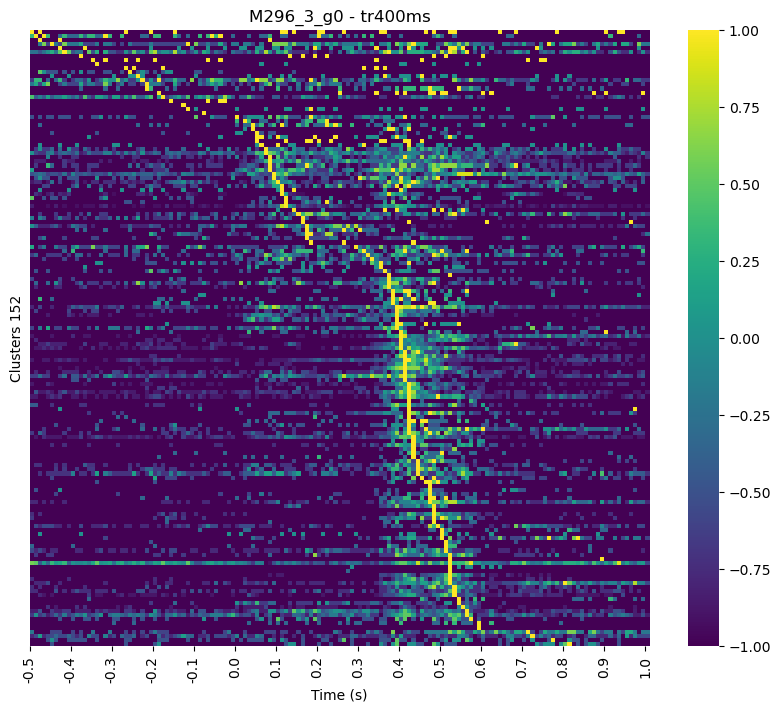

In [204]:
plot_heatmap(scaled_psth, recording, curr_stim_name, unit_type, roi, cell_type, exclude_zero_rows=True)

## PSTH

We have "spikes", "stims"

Index in psth is cluster number

In [200]:
curr_cluster = 0
curr_psth = psth[curr_cluster]
bin_size = 0.01
psth_counts = curr_psth.count(bin_size)

Index in curr_psth is trial number  
Index in psth_counts is time and columns are trials 

In [201]:
def plot_peth(psth, psth_counts, ax_mean, ax_spikes, color=None):
    # Plot raster plot
    ax_spikes.plot(psth.to_tsd(), ".", markersize=4, color=color) #psth.to_tsd() gets spike times and a column of what trial they belong to for raster
    ax_mean.set_xlabel("Time [s]")
    ax_spikes.set_ylabel("Trials")
    ax_spikes.axvline(0.0, color="red", linestyle="--")
    
    # Plot average trace across trials
    mean = np.mean(psth_counts / bin_size, axis=1) 
    ax_mean.plot(mean, linewidth=1, color=color)
    ax_mean.set_ylabel("Firing Rate")
    ax_mean.axvline(0.0, color="red", linestyle="--")

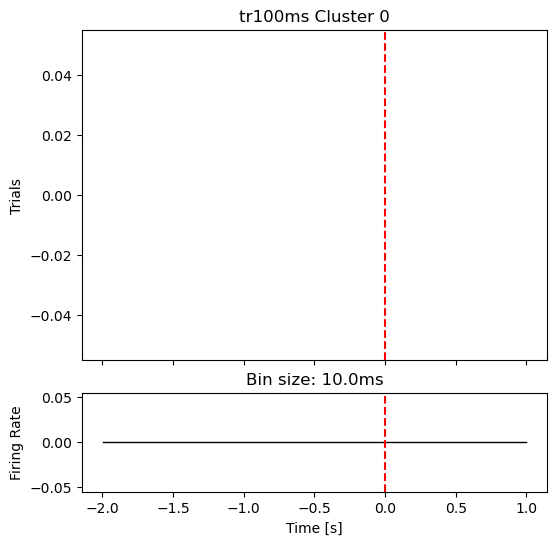

In [202]:
fig, (ax_spikes, ax_mean) = plt.subplots(2, 1, sharex=True, height_ratios=[1, 0.3], figsize=(6, 6), gridspec_kw={"hspace": 0.15})
plot_peth(curr_psth, psth_counts, ax_mean, ax_spikes, color="k")
ax_spikes.set_title(f"{curr_stim_name} Cluster {curr_cluster}")
ax_mean.set_title(f"Bin size: {bin_size * 1000}ms");

FIN